In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import folium
from folium.plugins import HeatMap
import json
import warnings
warnings.filterwarnings('ignore')

# Load all processed data
df = pd.read_csv("../data/processed/civilisations_clean.csv")
stressors = pd.read_csv("../data/raw/external_stressors.csv")
clusters_df = pd.read_csv("../data/processed/collapse_clusters.csv")
centrality_df = pd.read_csv("../data/processed/network_centrality.csv")
shap_importance = pd.read_csv("../data/processed/shap_importance.csv")
survival_df = pd.read_csv("../data/processed/survival_probabilities.csv")
alignment_df = pd.read_csv("../data/processed/cluster_stressor_alignment.csv")

with open("../data/processed/pillar_1_2_results.json") as f:
    results = json.load(f)

REGION_COLOURS = {
    'Europe': '#4E79A7', 'Middle East': '#F28E2B',
    'East Asia': '#E15759', 'Africa': '#76B7B2',
    'Americas': '#59A14F', 'South Asia': '#EDC948',
    'Central Asia': '#B07AA1'
}

TRIGGER_COLOURS = {
    'fragmentation': '#4E79A7', 'conquest': '#E15759',
    'overextension': '#F28E2B', 'climate': '#76B7B2',
    'migration': '#59A14F', 'economic': '#EDC948'
}

print("All data loaded successfully")
print(f"Civilisations: {len(df)}")
print(f"Stressor events: {len(stressors)}")

All data loaded successfully
Civilisations: 112
Stressor events: 20


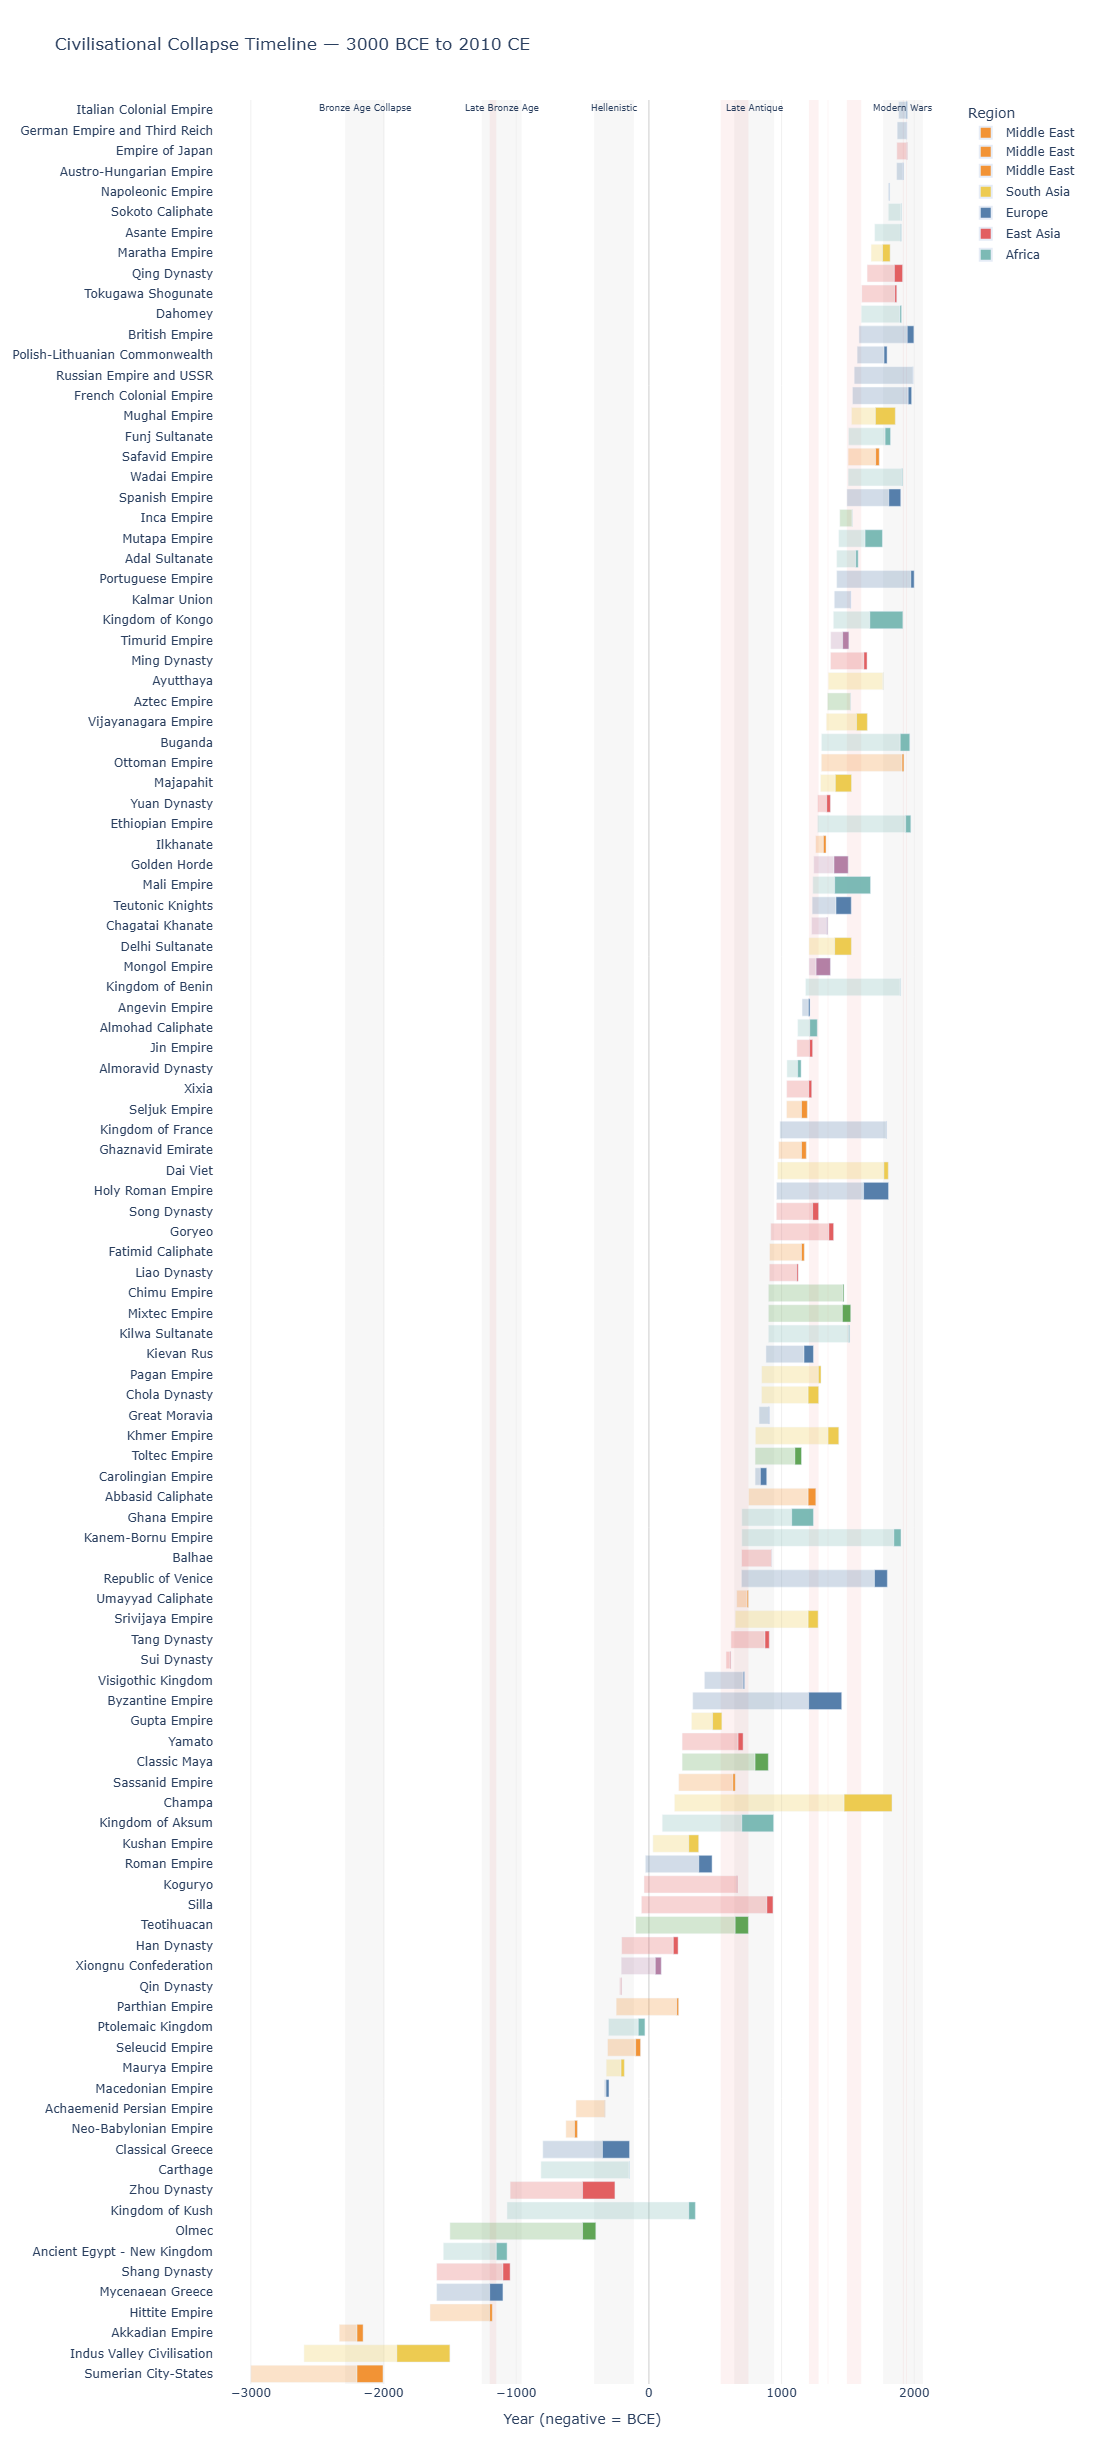

Timeline chart built and saved


In [2]:
def build_collapse_timeline(df, stressors, region_filter=None,
                             era_filter=None, show_stressors=True):
    """
    Interactive Gantt-style timeline showing civilisation lifespans
    and collapse windows. Returns a Plotly figure.
    """
    plot_df = df.copy()

    if region_filter:
        plot_df = plot_df[plot_df['region'].isin(region_filter)]
    if era_filter:
        plot_df = plot_df[plot_df['founding_era'].isin(era_filter)]

    plot_df = plot_df.sort_values('founded_year')

    fig = go.Figure()

    for i, (_, row) in enumerate(plot_df.iterrows()):
        colour = REGION_COLOURS.get(row['region'], '#999999')

        # Full lifespan bar — faint
        fig.add_trace(go.Bar(
            x=[row['collapse_start_year'] - row['founded_year']],
            y=[row['name']],
            base=[row['founded_year']],
            orientation='h',
            marker_color=colour,
            opacity=0.25,
            showlegend=False,
            hoverinfo='skip'
        ))

        # Collapse window — bold
        hover_text = (
            f"<b>{row['name']}</b><br>"
            f"Founded: {abs(int(row['founded_year']))} "
            f"{'BCE' if row['founded_year'] < 0 else 'CE'}<br>"
            f"Collapse: {abs(int(row['collapse_start_year']))}–"
            f"{abs(int(row['collapse_end_year']))} "
            f"{'BCE' if row['collapse_end_year'] < 0 else 'CE'}<br>"
            f"Duration: {int(row['collapse_duration_years'])} years<br>"
            f"Lifespan: {int(row['lifespan_years'])} years<br>"
            f"Trigger: {row['primary_collapse_trigger']}<br>"
            f"Peak population: {row['peak_population_m']}M<br>"
            f"Survival probability: {row.get('survival_probability', 0):.1%}"
        )

        fig.add_trace(go.Bar(
            x=[row['collapse_duration_years']],
            y=[row['name']],
            base=[row['collapse_start_year']],
            orientation='h',
            marker_color=colour,
            opacity=0.95,
            name=row['region'],
            showlegend=i < len(REGION_COLOURS),
            legendgroup=row['region'],
            hovertemplate=hover_text + '<extra></extra>'
        ))

    # Cluster period shading
    cluster_years = [-2140, -1110, -263, 793, 1915]
    cluster_labels = ['Bronze Age\nCollapse', 'Late Bronze Age',
                      'Hellenistic', 'Late Antique', 'Modern Wars']

    for cy, cl in zip(cluster_years, cluster_labels):
        fig.add_vrect(
            x0=cy-150, x1=cy+150,
            fillcolor='rgba(200,200,200,0.15)',
            layer='below', line_width=0,
            annotation_text=cl,
            annotation_position='top',
            annotation_font_size=9
        )

    # Stressor overlay
    if show_stressors:
        for _, s in stressors[stressors['severity'] == 'catastrophic'].iterrows():
            fig.add_vrect(
                x0=s['start_year'], x1=s['end_year'],
                fillcolor='rgba(229,87,89,0.08)',
                layer='below', line_width=0
            )

    fig.update_layout(
        title='Civilisational Collapse Timeline — 3000 BCE to 2010 CE',
        xaxis_title='Year (negative = BCE)',
        barmode='overlay',
        height=max(500, len(plot_df) * 22),
        bargap=0.15,
        plot_bgcolor='white',
        paper_bgcolor='white',
        legend=dict(
            title='Region',
            itemsizing='constant',
            tracegroupgap=2
        ),
        xaxis=dict(
            showgrid=True,
            gridcolor='#f0f0f0',
            zeroline=True,
            zerolinecolor='#cccccc',
            zerolinewidth=1
        )
    )

    return fig


# Test it
fig_timeline = build_collapse_timeline(df, stressors)
fig_timeline.show()
fig_timeline.write_html("../data/processed/viz_timeline.html")
print("Timeline chart built and saved")

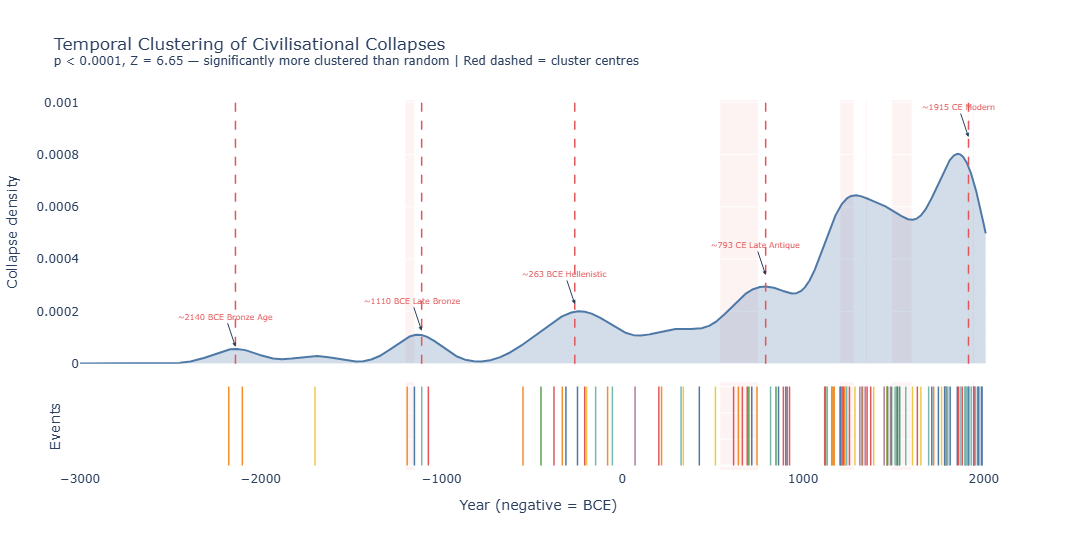

Density chart built and saved


In [3]:
def build_cluster_density_chart(df, stressors, clusters_df):
    """
    KDE density curve with cluster annotations
    and stressor overlay. Returns Plotly figure.
    """
    from scipy.stats import gaussian_kde

    years = ((df['collapse_start_year'] + df['collapse_end_year']) / 2).values
    year_std = years.std()
    bw_factor = 120 / year_std
    kde = gaussian_kde(years, bw_method=bw_factor)
    x_range = np.linspace(-3000, 2010, 5000)
    kde_values = kde(x_range)

    fig = make_subplots(
        rows=2, cols=1,
        row_heights=[0.75, 0.25],
        shared_xaxes=True,
        vertical_spacing=0.05
    )

    # KDE curve
    fig.add_trace(go.Scatter(
        x=x_range, y=kde_values,
        fill='tozeroy',
        fillcolor='rgba(78,121,167,0.25)',
        line=dict(color='#4E79A7', width=2),
        name='Collapse density',
        hovertemplate='Year: %{x:.0f}<br>Density: %{y:.6f}<extra></extra>'
    ), row=1, col=1)

    # Cluster markers
    cluster_years = [-2140, -1110, -263, 793, 1915]
    cluster_labels = ['~2140 BCE\nBronze Age', '~1110 BCE\nLate Bronze',
                      '~263 BCE\nHellenistic', '~793 CE\nLate Antique',
                      '~1915 CE\nModern']

    for cy, cl in zip(cluster_years, cluster_labels):
        fig.add_vline(x=cy, line_dash='dash',
                      line_color='#E15759', line_width=1.5,
                      row=1, col=1)
        kde_at_peak = kde(np.array([cy]))[0]
        fig.add_annotation(
            x=cy, y=kde_at_peak * 1.15,
            text=cl, showarrow=True,
            arrowhead=2, arrowsize=0.8,
            font=dict(size=8, color='#E15759'),
            row=1, col=1
        )

    # Individual collapse events as rug
    for _, row in df.iterrows():
        midpoint = (row['collapse_start_year'] + row['collapse_end_year']) / 2
        colour = REGION_COLOURS.get(row['region'], '#999999')
        fig.add_trace(go.Scatter(
            x=[midpoint, midpoint],
            y=[0, 0.3],
            mode='lines',
            line=dict(color=colour, width=1.5),
            showlegend=False,
            hovertemplate=f"{row['name']}<extra></extra>"
        ), row=2, col=1)

    # Catastrophic stressor shading
    for _, s in stressors[stressors['severity'] == 'catastrophic'].iterrows():
        for r in [1, 2]:
            fig.add_vrect(
                x0=s['start_year'], x1=s['end_year'],
                fillcolor='rgba(229,87,89,0.07)',
                layer='below', line_width=0,
                row=r, col=1
            )

    fig.update_layout(
        title=(
            'Temporal Clustering of Civilisational Collapses<br>'
            '<sup>p < 0.0001, Z = 6.65 — significantly more clustered than random'
            ' | Red dashed = cluster centres</sup>'
        ),
        height=550,
        plot_bgcolor='white',
        paper_bgcolor='white',
        showlegend=False
    )
    fig.update_xaxes(title_text='Year (negative = BCE)', row=2, col=1)
    fig.update_yaxes(title_text='Collapse density', row=1, col=1)
    fig.update_yaxes(title_text='Events', row=2, col=1,
                     showticklabels=False)

    return fig


fig_density = build_cluster_density_chart(df, stressors, clusters_df)
fig_density.show()
fig_density.write_html("../data/processed/viz_density.html")
print("Density chart built and saved")

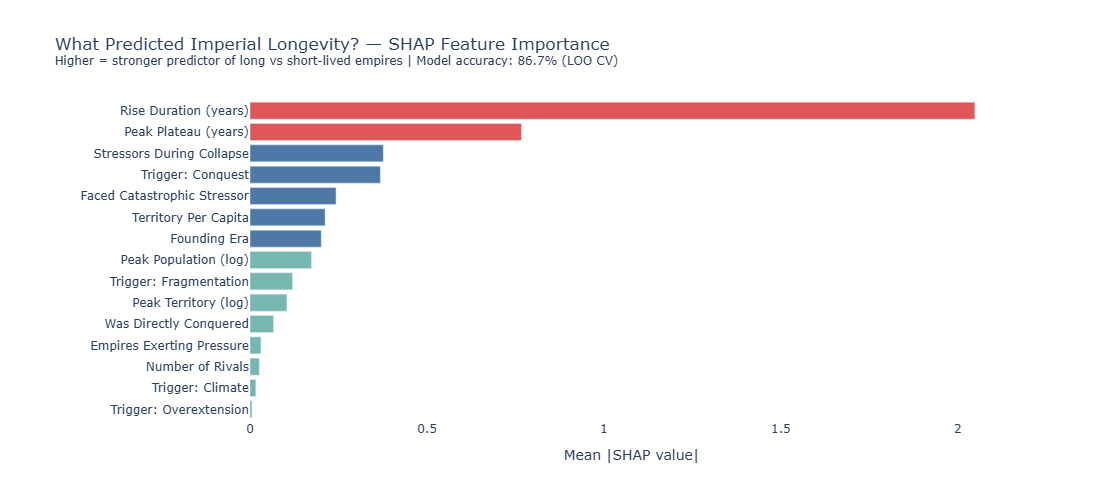

SHAP chart built and saved


In [4]:
def build_shap_chart(shap_importance):
    """Horizontal bar chart of SHAP feature importance."""
    plot_df = shap_importance.sort_values('mean_abs_shap')

    # Clean feature names for display
    label_map = {
        'rise_duration_years': 'Rise Duration (years)',
        'peak_plateau_years': 'Peak Plateau (years)',
        'n_contemporary_rivals': 'Number of Rivals',
        'founding_era_numeric': 'Founding Era',
        'n_stressors_during_collapse': 'Stressors During Collapse',
        'has_any_catastrophic': 'Faced Catastrophic Stressor',
        'n_pressuring_empires': 'Empires Exerting Pressure',
        'log_peak_population': 'Peak Population (log)',
        'was_conquered': 'Was Directly Conquered',
        'trigger_fragmentation': 'Trigger: Fragmentation',
        'territory_per_capita': 'Territory Per Capita',
        'log_peak_territory': 'Peak Territory (log)',
        'trigger_climate': 'Trigger: Climate',
        'trigger_conquest': 'Trigger: Conquest',
        'trigger_overextension': 'Trigger: Overextension'
    }

    plot_df['label'] = plot_df['feature'].map(label_map).fillna(plot_df['feature'])

    colours = ['#E15759' if v > 0.5 else '#4E79A7' if v > 0.2
               else '#76B7B2' for v in plot_df['mean_abs_shap']]

    fig = go.Figure(go.Bar(
        x=plot_df['mean_abs_shap'],
        y=plot_df['label'],
        orientation='h',
        marker_color=colours,
        hovertemplate='%{y}: %{x:.4f}<extra></extra>'
    ))

    fig.update_layout(
        title=(
            'What Predicted Imperial Longevity? — SHAP Feature Importance<br>'
            '<sup>Higher = stronger predictor of long vs short-lived empires'
            ' | Model accuracy: 86.7% (LOO CV)</sup>'
        ),
        xaxis_title='Mean |SHAP value|',
        height=500,
        plot_bgcolor='white',
        paper_bgcolor='white',
        margin=dict(l=250)
    )

    return fig


fig_shap = build_shap_chart(shap_importance)
fig_shap.show()
fig_shap.write_html("../data/processed/viz_shap.html")
print("SHAP chart built and saved")

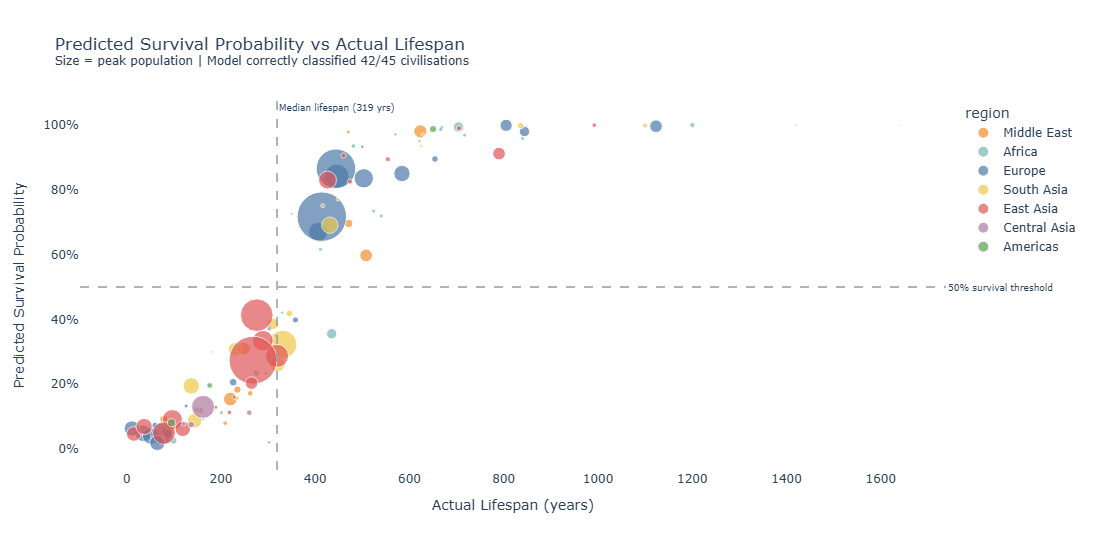

Survival scatter built and saved


In [5]:
def build_survival_scatter(survival_df):
    plot_df = survival_df.merge(
        df[['name', 'region', 'peak_population_m',
            'primary_collapse_trigger', 'founding_era']],
        on='name',
        how='left',
        suffixes=('', '_drop')
    )
    # Drop duplicate columns from merge
    plot_df = plot_df[[c for c in plot_df.columns
                       if not c.endswith('_drop')]]

    fig = px.scatter(
        plot_df,
        x='lifespan_years',
        y='survival_probability',
        color='region',
        size='peak_population_m',
        hover_name='name',
        hover_data={
            'lifespan_years': True,
            'survival_probability': ':.1%',
            'primary_collapse_trigger': True,
            'founding_era': True,
            'peak_population_m': ':.0f',
            'region': False
        },
        color_discrete_map=REGION_COLOURS,
        size_max=35,
        title=(
            'Predicted Survival Probability vs Actual Lifespan<br>'
            '<sup>Size = peak population | '
            'Model correctly classified 42/45 civilisations</sup>'
        )
    )

    fig.add_vline(
        x=319, line_dash='dash',
        line_color='#999999', line_width=1.5,
        annotation_text='Median lifespan (319 yrs)',
        annotation_position='top right',
        annotation_font_size=9
    )

    fig.add_hline(
        y=0.5, line_dash='dash',
        line_color='#999999', line_width=1.5,
        annotation_text='50% survival threshold',
        annotation_position='right',
        annotation_font_size=9
    )

    fig.update_layout(
        height=550,
        plot_bgcolor='white',
        paper_bgcolor='white',
        xaxis_title='Actual Lifespan (years)',
        yaxis_title='Predicted Survival Probability',
        yaxis_tickformat='.0%'
    )

    return fig


fig_survival = build_survival_scatter(survival_df)
fig_survival.show()
fig_survival.write_html("../data/processed/viz_survival.html")
print("Survival scatter built and saved")

In [6]:
def build_collapse_map(df, clusters=None):
    """
    Folium map showing collapse locations,
    sized by peak territory, coloured by trigger.
    """
    m = folium.Map(
        location=[25, 20],
        zoom_start=2,
        tiles='CartoDB positron'
    )

    TRIGGER_HEX = {
        'fragmentation': '#4E79A7',
        'conquest': '#E15759',
        'overextension': '#F28E2B',
        'climate': '#76B7B2',
        'migration': '#59A14F',
        'economic': '#EDC948'
    }

    # Add cluster circles
    cluster_years = [-2140, -1110, -263, 793, 1915]
    cluster_labels = ['Bronze Age ~2140 BCE', 'Late Bronze ~1110 BCE',
                      'Hellenistic ~263 BCE', 'Late Antique ~793 CE',
                      'Modern ~1915 CE']

    for cy, cl in zip(cluster_years, cluster_labels):
        cluster_civs = df[
            (df['collapse_start_year'] + df['collapse_end_year']) / 2
            >= cy - 150
        ]
        cluster_civs = cluster_civs[
            (cluster_civs['collapse_start_year'] + cluster_civs['collapse_end_year']) / 2
            <= cy + 150
        ]

    # Add civilisation markers
    for _, row in df.iterrows():
        colour = TRIGGER_HEX.get(row['primary_collapse_trigger'], '#999999')
        radius = max(5, min(25, row['peak_territory_km2'] / 1000000 * 3))

        # Collapse year label
        c_start = int(row['collapse_start_year'])
        c_end = int(row['collapse_end_year'])
        start_str = f"{abs(c_start)} {'BCE' if c_start < 0 else 'CE'}"
        end_str = f"{abs(c_end)} {'BCE' if c_end < 0 else 'CE'}"

        popup_html = f"""
        <div style='font-family: sans-serif; width: 220px'>
            <h4 style='margin:0; color: {colour}'>{row['name']}</h4>
            <hr style='margin: 4px 0'>
            <b>Region:</b> {row['region']}<br>
            <b>Founded:</b> {abs(int(row['founded_year']))}
                {'BCE' if row['founded_year'] < 0 else 'CE'}<br>
            <b>Collapse:</b> {start_str} → {end_str}<br>
            <b>Duration:</b> {int(row['collapse_duration_years'])} years<br>
            <b>Lifespan:</b> {int(row['lifespan_years'])} years<br>
            <b>Primary trigger:</b> {row['primary_collapse_trigger']}<br>
            <b>Peak population:</b> {row['peak_population_m']}M<br>
            <b>Peak territory:</b>
                {row['peak_territory_km2']:,} km²<br>
            <b>Survival probability:</b>
                {row.get('survival_probability', 0):.1%}
        </div>
        """

        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=radius,
            color=colour,
            fill=True,
            fill_color=colour,
            fill_opacity=0.7,
            popup=folium.Popup(popup_html, max_width=250),
            tooltip=f"{row['name']} — click for details"
        ).add_to(m)

    # Collapse heatmap layer
    heat_data = [[row['latitude'], row['longitude'], 1]
                 for _, row in df.iterrows()]
    HeatMap(heat_data, radius=30, blur=20,
            name='Collapse density heatmap').add_to(m)

    folium.LayerControl().add_to(m)

    # Legend
    legend_html = """
    <div style='position: fixed; bottom: 30px; left: 30px;
                background: white; padding: 12px; border-radius: 8px;
                border: 1px solid #ccc; font-family: sans-serif;
                font-size: 12px; z-index: 1000'>
        <b>Primary Collapse Trigger</b><br>
    """
    for trigger, colour in TRIGGER_HEX.items():
        legend_html += (f"<span style='color:{colour}'>●</span> "
                       f"{trigger.capitalize()}<br>")
    legend_html += "<br><i>Circle size = peak territory</i></div>"

    m.get_root().html.add_child(folium.Element(legend_html))
    m.save("../data/processed/viz_collapse_map.html")
    print("Folium map saved: viz_collapse_map.html")
    return m


collapse_map = build_collapse_map(df)
collapse_map

Folium map saved: viz_collapse_map.html


In [7]:
import os

viz_files = [
    "../data/processed/viz_timeline.html",
    "../data/processed/viz_density.html",
    "../data/processed/viz_shap.html",
    "../data/processed/viz_survival.html",
    "../data/processed/viz_collapse_map.html",
]

print("=== VISUALISATION FILES ===")
all_good = True
for f in viz_files:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1024
        print(f"  ✓ {f.split('/')[-1]} ({size:.0f} KB)")
    else:
        print(f"  ✗ MISSING: {f}")
        all_good = False

if all_good:
    print(f"\nAll {len(viz_files)} visualisation files ready")
    print("Phase 9 complete — ready for Phase 10 Streamlit dashboard")
else:
    print("\nSome files missing — check errors above")

=== VISUALISATION FILES ===
  ✓ viz_timeline.html (4819 KB)
  ✓ viz_density.html (4887 KB)
  ✓ viz_shap.html (4741 KB)
  ✓ viz_survival.html (4756 KB)
  ✓ viz_collapse_map.html (216 KB)

All 5 visualisation files ready
Phase 9 complete — ready for Phase 10 Streamlit dashboard
